# 03 — Descomposicion estacional

Cuantificar la componente estacional del IPC para decidir si la diferenciacion
estacional (D=1 en SARIMA) es necesaria.

**Metodos:**
- Descomposicion clasica (aditiva y multiplicativa)
- STL (Seasonal-Trend decomposition using LOESS) — mas robusto a outliers
- Analisis de la fuerza estacional (Fs)

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose, STL

NOTEBOOK_DIR = Path(r"c:/Users/usuario/OneDrive/Documentos/tfg-ipc-mcp/tfg-forecasting/02_eda")
ROOT = NOTEBOOK_DIR.parent
MONOREPO = ROOT.parent
sys.path.insert(0, str(MONOREPO))

from shared.constants import DATE_TRAIN_END

plt.rcParams.update({"figure.figsize": (14, 8), "axes.grid": True, "grid.alpha": 0.3})

In [2]:
df = pd.read_parquet(ROOT / "data" / "processed" / "ipc_spain_index.parquet")
train = df.loc[:DATE_TRAIN_END]
y = train["indice_general"]
y.index.freq = "MS"
print(f"Train: {len(y)} obs, {y.index.min().date()} -> {y.index.max().date()}")

Train: 228 obs, 2002-01-01 -> 2020-12-01


## 1. Descomposicion clasica — aditiva

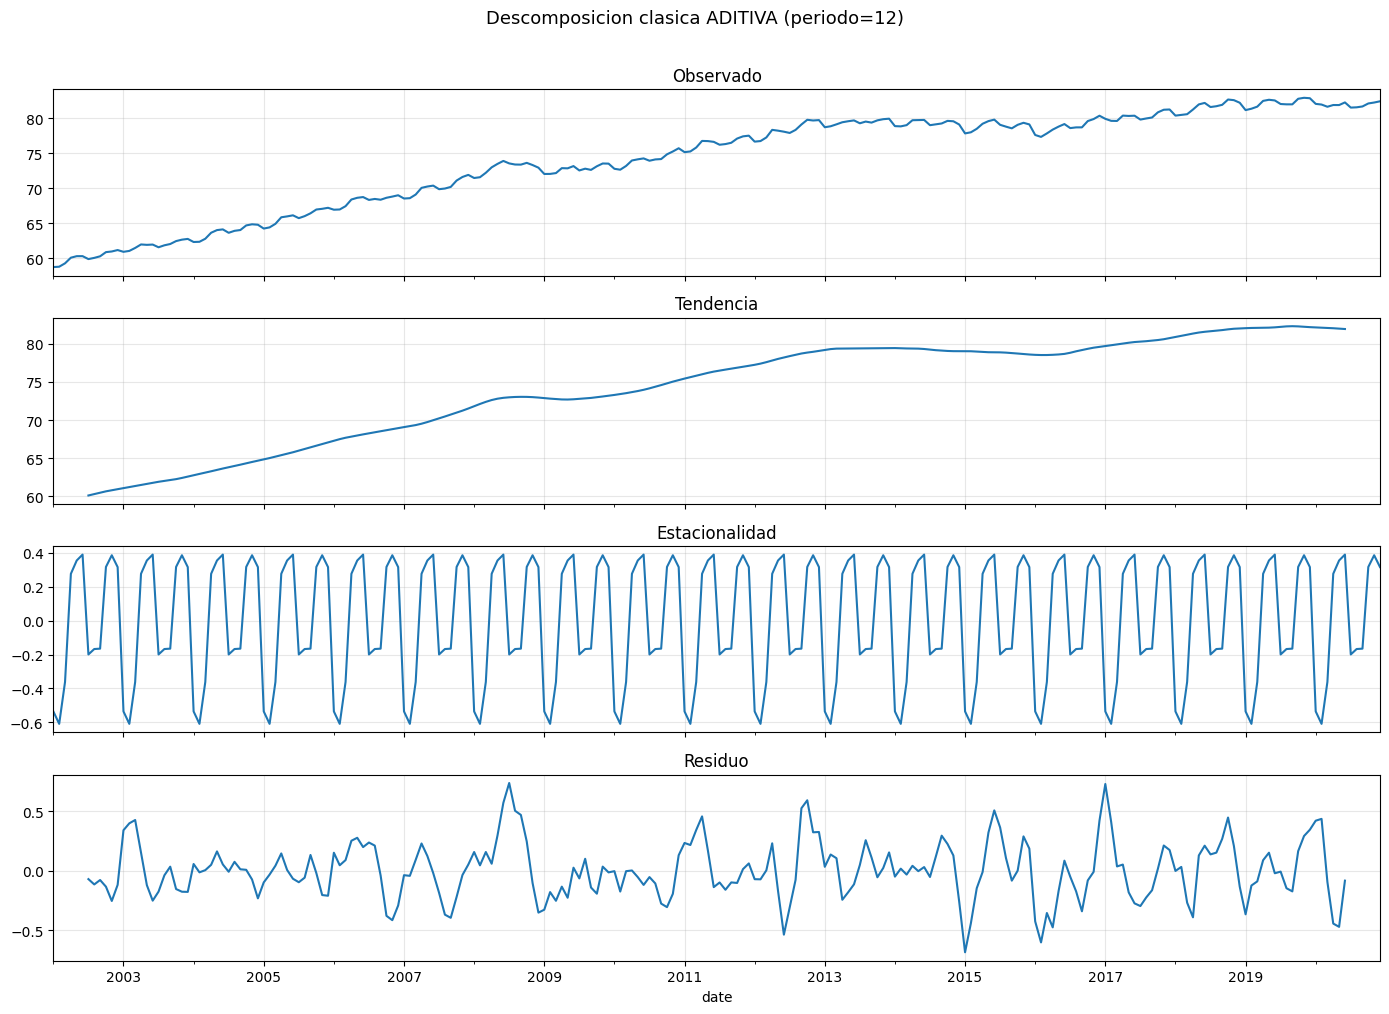

In [3]:
decomp_add = seasonal_decompose(y, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomp_add.observed.plot(ax=axes[0], title="Observado")
decomp_add.trend.plot(ax=axes[1], title="Tendencia")
decomp_add.seasonal.plot(ax=axes[2], title="Estacionalidad")
decomp_add.resid.plot(ax=axes[3], title="Residuo")
fig.suptitle("Descomposicion clasica ADITIVA (periodo=12)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 2. Descomposicion clasica — multiplicativa

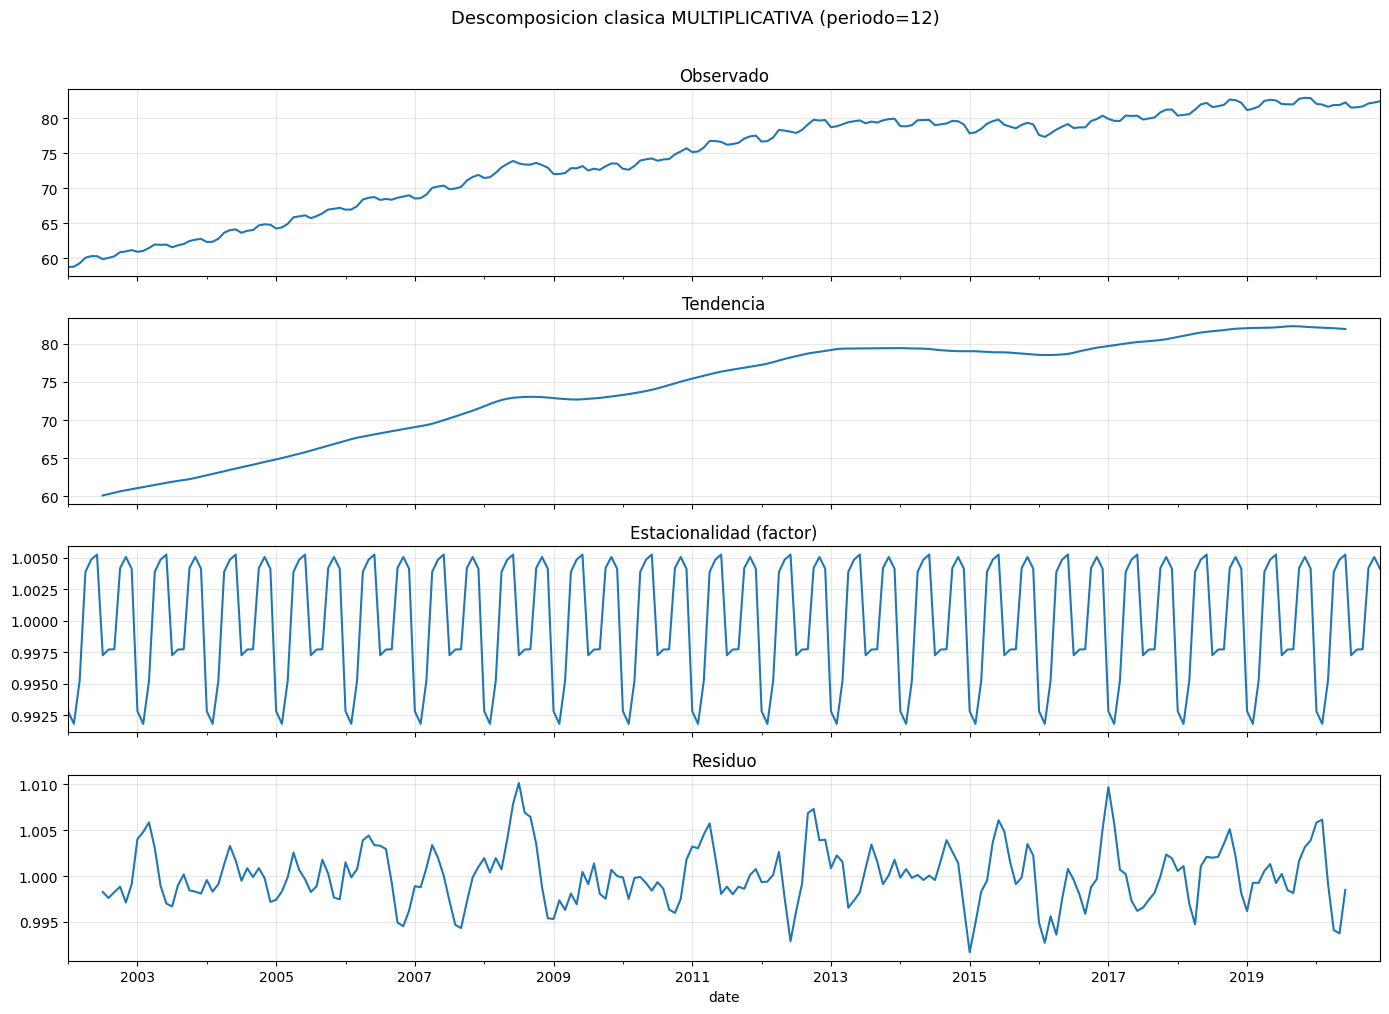

In [4]:
decomp_mul = seasonal_decompose(y, model="multiplicative", period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomp_mul.observed.plot(ax=axes[0], title="Observado")
decomp_mul.trend.plot(ax=axes[1], title="Tendencia")
decomp_mul.seasonal.plot(ax=axes[2], title="Estacionalidad (factor)")
decomp_mul.resid.plot(ax=axes[3], title="Residuo")
fig.suptitle("Descomposicion clasica MULTIPLICATIVA (periodo=12)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 3. STL (LOESS) — robusto a outliers

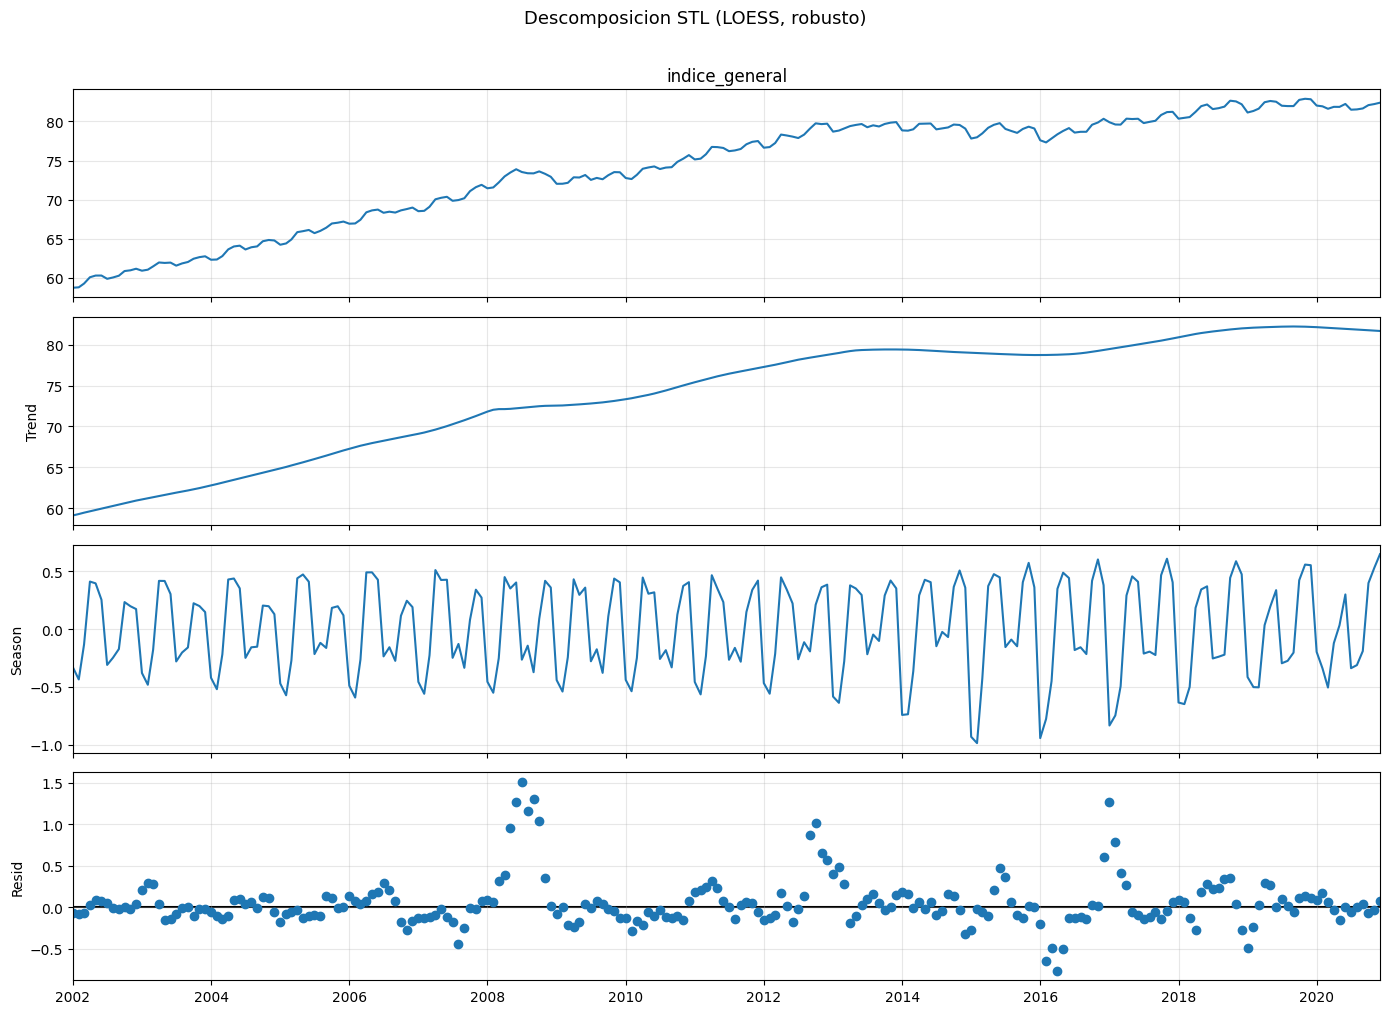

In [5]:
stl = STL(y, period=12, robust=True)
stl_result = stl.fit()

fig = stl_result.plot()
fig.set_size_inches(14, 10)
fig.suptitle("Descomposicion STL (LOESS, robusto)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 4. Fuerza de la estacionalidad (Fs)

Metrica de Wang, Smith & Hyndman (2006):

$F_s = 1 - \frac{\text{Var}(R_t)}{\text{Var}(S_t + R_t)}$

- $F_s > 0.64$ indica estacionalidad significativa
- $F_s$ cercano a 1 indica estacionalidad muy fuerte

In [6]:
seasonal = stl_result.seasonal
resid = stl_result.resid

Fs = 1 - np.var(resid) / np.var(seasonal + resid)
print(f"Fuerza estacional (Fs): {Fs:.4f}")
print(f"Estacionalidad {'SIGNIFICATIVA' if Fs > 0.64 else 'NO significativa'} (umbral 0.64)")

Fuerza estacional (Fs): 0.6191
Estacionalidad NO significativa (umbral 0.64)


## 5. Patron estacional mensual

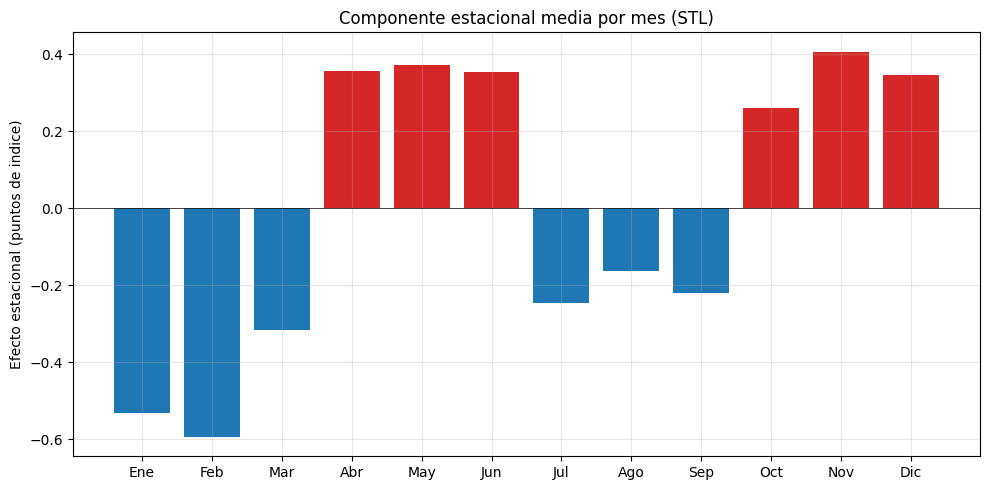

Patron estacional mensual:
  Ene: -0.531
  Feb: -0.594
  Mar: -0.316
  Abr: +0.355
  May: +0.372
  Jun: +0.355
  Jul: -0.245
  Ago: -0.164
  Sep: -0.220
  Oct: +0.261
  Nov: +0.406
  Dic: +0.345


In [7]:
seasonal_pattern = stl_result.seasonal.groupby(stl_result.seasonal.index.month).mean()

fig, ax = plt.subplots(figsize=(10, 5))
months = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
colors = ["#d62728" if v > 0 else "#1f77b4" for v in seasonal_pattern.values]
ax.bar(range(1, 13), seasonal_pattern.values, color=colors)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(months)
ax.set_title("Componente estacional media por mes (STL)")
ax.set_ylabel("Efecto estacional (puntos de indice)")
ax.axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

print("Patron estacional mensual:")
for m, name in enumerate(months, 1):
    print(f"  {name}: {seasonal_pattern[m]:+.3f}")

## 6. Estabilidad temporal de la estacionalidad

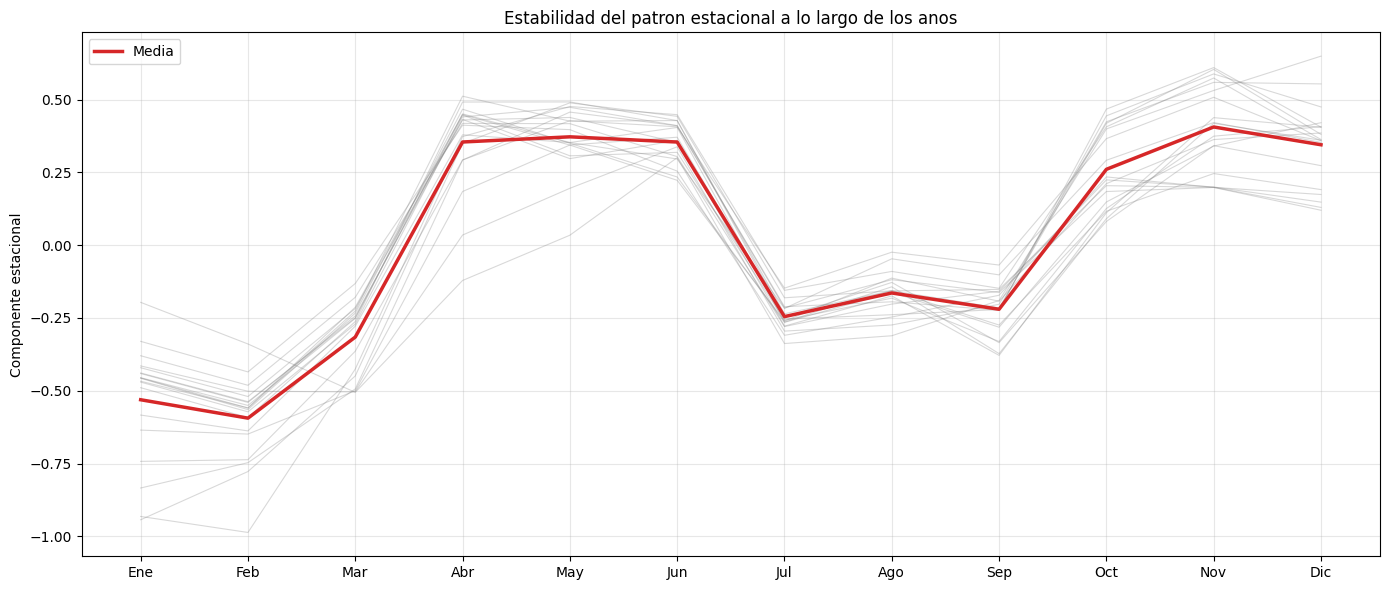

In [8]:
seasonal_by_year = stl_result.seasonal.copy()
seasonal_by_year = pd.DataFrame({
    "year": seasonal_by_year.index.year,
    "month": seasonal_by_year.index.month,
    "seasonal": seasonal_by_year.values,
})

pivot = seasonal_by_year.pivot(index="month", columns="year", values="seasonal")

fig, ax = plt.subplots(figsize=(14, 6))
for col in pivot.columns:
    ax.plot(pivot.index, pivot[col], alpha=0.3, linewidth=0.8, color="grey")

# Media superpuesta
ax.plot(pivot.index, pivot.mean(axis=1), linewidth=2.5, color="#d62728", label="Media")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(months)
ax.set_title("Estabilidad del patron estacional a lo largo de los anos")
ax.set_ylabel("Componente estacional")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Conclusion

**Resultados clave:**
- La descomposicion STL muestra tendencia creciente con aceleracion post-2021
- Fs cuantifica la fuerza de la estacionalidad
- El patron estacional identifica los meses con mayor/menor efecto
- Si Fs > 0.64, la diferenciacion estacional (D=1, m=12) esta justificada para SARIMA

*Completar tras ejecucion con los valores reales de Fs y el patron mensual.*